# Alpha Research: BBIBOLL Factor Analysis

**Objective**: Convert the BBIBOLL deviation (a rule-based trading signal) into a
cross-sectional factor and evaluate its predictive power using the `src/alpha/` framework.

**Pipeline**:
1. Load OHLCV data for ~50 liquid US stocks (2 years)
2. Compute BBIBOLL indicator → extract deviation signal
3. Compute forward returns at multiple horizons
4. Run `FactorAnalyzer` — IC, IR, IC decay, turnover
5. Preprocess (winsorize + z-score) and compare
6. Visualize: IC time series, IC decay curve, quantile returns

**Reference**: `docs/quant_lab.tex` — Part III, Chapters 9-12

## 0. Setup

In [4]:
import sys
from pathlib import Path

# Add src/ to path so we can import project modules
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Clear any cached project modules (so edits to src/ are picked up)
for mod_name in list(sys.modules.keys()):
    if any(mod_name.startswith(p) for p in ("config", "data.", "strategy.", "alpha.", "backtest.", "utils.")):
        del sys.modules[mod_name]

print(f"Project root: {PROJECT_ROOT}")
print(f"src/ added to path: {SRC_DIR}")

Project root: /home/jerryhong/code-projects/quant101
src/ added to path: /home/jerryhong/code-projects/quant101/src


In [5]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# Project imports
from data.universe import get_universe
from data.loader.data_loader import stock_load_process
from indicators.registry import get_indicator
# from indicators.bbiboll_indicator import calculate_bbiboll  # noqa: F401 — registers the indicator
from alpha.forward_returns import compute_forward_returns
from alpha.factor_analyzer import FactorAnalyzer
from alpha.preprocessing import preprocess_factor

# Plotting style
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("Imports OK ✅")

Imports OK ✅


## 1. Load OHLCV Data

Load ~50 liquid US stocks over 2 years of daily bars.
We use a hand-picked universe of large-cap names to keep it fast.

In [6]:
UNIVERSE = get_universe("US_LARGE_CAP_50")
START_DATE = "2023-01-01"
END_DATE = "2026-02-28"

print(f"Universe: {len(UNIVERSE)} stocks")
print(f"Period: {START_DATE} → {END_DATE}")

Universe: 51 stocks
Period: 2023-01-01 → 2026-02-28


In [7]:
# Load OHLCV via the data pipeline
ohlcv_lf = stock_load_process(
    tickers=UNIVERSE,
    start_date=START_DATE,
    end_date=END_DATE,
    timeframe="1d",
    use_cache=True,
    skip_low_volume=False,
)

ohlcv = ohlcv_lf.collect()
print(f"Shape: {ohlcv.shape}")
print(f"Tickers loaded: {ohlcv['ticker'].n_unique()}")
print(f"Date range: {ohlcv['timestamps'].min()} → {ohlcv['timestamps'].max()}")
ohlcv.head(5)

Loading from cache: /mnt/blackdisk/quant_data/polygon_data/processed/us_stocks_sip/day_aggs_v1/cache_c5e11349e9e04e8bdef2634ae48ac375.parquet
Cache loaded: 40,301 rows, 2.58 MB
Shape: (40301, 10)
Tickers loaded: 52
Date range: 2023-01-03 00:00:00-05:00 → 2026-02-26 00:00:00-05:00


ticker,timestamps,volume,open,close,high,low,window_start,transactions,split_date
str,"datetime[ns, America/New_York]",i64,f64,f64,f64,f64,i64,u32,date
"""AAPL""",2023-01-03 00:00:00 EST,111849813,130.28,125.07,130.9,124.17,1672722000000000000,1021048,null
"""AAPL""",2023-01-04 00:00:00 EST,88164019,126.89,126.36,128.6557,125.08,1672808400000000000,770033,null
"""AAPL""",2023-01-05 00:00:00 EST,80016812,127.13,125.02,127.77,124.76,1672894800000000000,665452,null
"""AAPL""",2023-01-06 00:00:00 EST,87625842,126.01,129.62,130.29,124.89,1672981200000000000,711505,null
"""AAPL""",2023-01-09 00:00:00 EST,70697486,130.465,130.15,133.41,129.89,1673240400000000000,645363,null


## 2. Compute BBIBOLL Indicator

Apply the BBIBOLL indicator (BBI + Bollinger deviation) to each stock.
The `dev` column measures how far the BBI is from its rolling mean in
standard-deviation units — this is our raw signal.

In [8]:
# Apply BBIBOLL indicator via the registry
bbiboll_fn = get_indicator("bbiboll")
ohlcv_with_bbiboll = bbiboll_fn(ohlcv)

print(f"Columns after BBIBOLL: {ohlcv_with_bbiboll.columns}")
ohlcv_with_bbiboll.select(["ticker", "timestamps", "close", "bbi", "dev", "upr", "dwn"]).tail(10)

Columns after BBIBOLL: ['ticker', 'timestamps', 'volume', 'open', 'close', 'high', 'low', 'window_start', 'transactions', 'split_date', 'bbi', 'dev', 'upr', 'dwn', 'dev_pct', 'longterm_dev_pct_rank']


ticker,timestamps,close,bbi,dev,upr,dwn
str,"datetime[ns, America/New_York]",f64,f64,f64,f64,f64
"""XOM""",2026-02-12 00:00:00 EST,149.93,146.843333,26.195812,173.039146,120.647521
"""XOM""",2026-02-13 00:00:00 EST,148.45,147.155208,25.748901,172.90411,121.406307
"""XOM""",2026-02-17 00:00:00 EST,146.19,146.604375,24.160395,170.76477,122.44398
"""XOM""",2026-02-18 00:00:00 EST,150.68,147.089583,21.607521,168.697104,125.482063
"""XOM""",2026-02-19 00:00:00 EST,150.97,147.751979,18.674473,166.426453,129.077506
"""XOM""",2026-02-20 00:00:00 EST,147.28,147.760833,15.529756,163.290589,132.231077
"""XOM""",2026-02-23 00:00:00 EST,150.76,148.085521,12.528687,160.614208,135.556833
"""XOM""",2026-02-24 00:00:00 EST,149.26,148.238854,9.494999,157.733853,138.743855
"""XOM""",2026-02-25 00:00:00 EST,149.06,148.667917,6.654666,155.322583,142.013251


## 3. Extract Factor Signal

Convert the BBIBOLL deviation into the standard factor format: `(date, ticker, value)`.

The signal: **close - bbi** (deviation of close price from BBI mean).
When this is positive, the stock is trading above its multi-timeframe moving average.
When negative, it's trading below.

We normalize by `dev` to get a z-score-like signal: `(close - bbi) / dev`.

In [9]:
# Extract the BBIBOLL deviation signal: (close - bbi) / dev
# This measures how many BBI-standard-deviations the close is from BBI
signal_df = (
    ohlcv_with_bbiboll
    .with_columns(
        ((pl.col("close") - pl.col("bbi")) / pl.col("dev")).alias("value"),
    )
    .filter(
        pl.col("value").is_not_null()
        & pl.col("value").is_not_nan()
        & pl.col("value").is_finite()
    )
    .select([
        pl.col("timestamps").alias("date"),
        pl.col("ticker"),
        pl.col("value"),
    ])
)
print(f"Signal sample:")
print(signal_df.head(10))
print(f"Signal shape: {signal_df.shape}")
print(f"Signal stats:")
signal_df.select("value").describe()

Signal sample:
shape: (10, 3)
┌────────────────────────────────┬────────┬───────────┐
│ date                           ┆ ticker ┆ value     │
│ ---                            ┆ ---    ┆ ---       │
│ datetime[ns, America/New_York] ┆ str    ┆ f64       │
╞════════════════════════════════╪════════╪═══════════╡
│ 2023-02-21 00:00:00 EST        ┆ AAPL   ┆ -0.257472 │
│ 2023-02-22 00:00:00 EST        ┆ AAPL   ┆ -0.201393 │
│ 2023-02-23 00:00:00 EST        ┆ AAPL   ┆ -0.121458 │
│ 2023-02-24 00:00:00 EST        ┆ AAPL   ┆ -0.504436 │
│ 2023-02-27 00:00:00 EST        ┆ AAPL   ┆ -0.259968 │
│ 2023-02-28 00:00:00 EST        ┆ AAPL   ┆ -0.285156 │
│ 2023-03-01 00:00:00 EST        ┆ AAPL   ┆ -0.556254 │
│ 2023-03-02 00:00:00 EST        ┆ AAPL   ┆ -0.324358 │
│ 2023-03-03 00:00:00 EST        ┆ AAPL   ┆ 0.350276  │
│ 2023-03-06 00:00:00 EST        ┆ AAPL   ┆ 0.646475  │
└────────────────────────────────┴────────┴───────────┘
Signal shape: (38585, 3)
Signal stats:


statistic,value
str,f64
"""count""",38585.0
"""null_count""",0.0
"""mean""",0.041669
"""std""",0.491171
"""min""",-3.692684
"""25%""",-0.222307
"""50%""",0.070691
"""75%""",0.307088
"""max""",3.996575


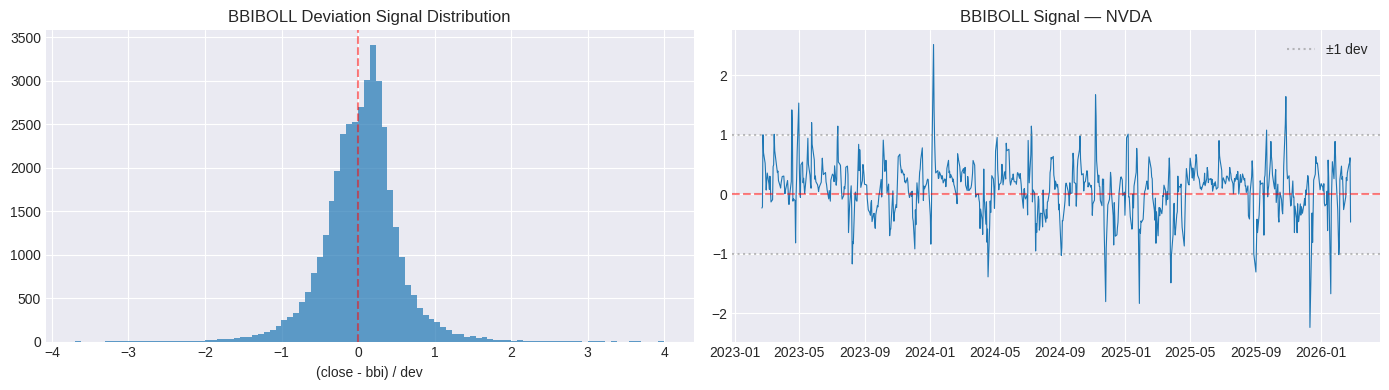

In [10]:
# Quick sanity check: distribution of signal values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

values = signal_df["value"].to_numpy()
axes[0].hist(values[np.isfinite(values)], bins=100, edgecolor="none", alpha=0.7)
axes[0].set_title("BBIBOLL Deviation Signal Distribution")
axes[0].set_xlabel("(close - bbi) / dev")
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)

# Signal over time for one stock
sample_ticker = "NVDA"
sample = signal_df.filter(pl.col("ticker") == sample_ticker).sort("date")
axes[1].plot(sample["date"].to_list(), sample["value"].to_list(), linewidth=0.8)
axes[1].set_title(f"BBIBOLL Signal — {sample_ticker}")
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[1].axhline(1, color="gray", linestyle=":", alpha=0.5, label="±1 dev")
axes[1].axhline(-1, color="gray", linestyle=":", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Compute Forward Returns

Using `compute_forward_returns()` from `src/alpha/forward_returns.py`.
This computes the N-day simple return for each stock at each date.

In [11]:
HORIZONS = [1, 2, 5, 10, 20]

returns_df = compute_forward_returns(
    ohlcv,
    horizons=HORIZONS,
    price_col="close",
    date_col="timestamps",
    ticker_col="ticker",
)

print(f"Returns shape: {returns_df.shape}")
print(f"Columns: {returns_df.columns}")
returns_df.head(5)

Returns shape: (40301, 7)
Columns: ['date', 'ticker', 'forward_return_1d', 'forward_return_2d', 'forward_return_5d', 'forward_return_10d', 'forward_return_20d']


date,ticker,forward_return_1d,forward_return_2d,forward_return_5d,forward_return_10d,forward_return_20d
"datetime[ns, America/New_York]",str,f64,f64,f64,f64,f64
2023-01-03 00:00:00 EST,"""AAPL""",0.010314,-0.0004,0.045255,0.081075,0.162789
2023-01-04 00:00:00 EST,"""AAPL""",-0.010605,0.025799,0.056426,0.070513,0.193574
2023-01-05 00:00:00 EST,"""AAPL""",0.036794,0.041033,0.067109,0.102784,0.235802
2023-01-06 00:00:00 EST,"""AAPL""",0.004089,0.008563,0.039654,0.088644,0.170576
2023-01-09 00:00:00 EST,"""AAPL""",0.004456,0.025663,0.044487,0.095121,0.188244


## 5. Factor Analysis — Raw Signal

Run `FactorAnalyzer` on the raw BBIBOLL deviation signal.
This answers: *does this signal predict future cross-sectional returns?*

In [12]:
analyzer = FactorAnalyzer(signal_df, returns_df, min_observations=30)

# Full summary at 5-day horizon
raw_summary = analyzer.summary(horizon=5)


Factor Evaluation Summary (horizon=5d)
  Mean IC:          0.0030
  Std IC:           0.2093
  IR:               0.0144
  t-stat:           0.3948
  Hit Rate:          50.7%
  # Dates:             752
  Mean Turnover:    0.3090
  ⚠️  Not significant (|t| = 0.39 < 2)
  ⚠️  Weak factor (|IR| = 0.01 < 0.3)



In [13]:
# IC decay across horizons
decay_df = analyzer.ic_decay(horizons=HORIZONS)
print("IC Decay:")
print(decay_df)

IC Decay:
shape: (5, 5)
┌─────────┬───────────┬──────────┬───────────┬───────────┐
│ horizon ┆ mean_ic   ┆ std_ic   ┆ ir        ┆ t_stat    │
│ ---     ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ i64     ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞═════════╪═══════════╪══════════╪═══════════╪═══════════╡
│ 1       ┆ 0.004044  ┆ 0.224678 ┆ 0.018     ┆ 0.49492   │
│ 2       ┆ 0.004116  ┆ 0.223944 ┆ 0.018378  ┆ 0.504964  │
│ 5       ┆ 0.003014  ┆ 0.209337 ┆ 0.014396  ┆ 0.394777  │
│ 10      ┆ -0.01098  ┆ 0.217595 ┆ -0.050461 ┆ -1.37916  │
│ 20      ┆ -0.012756 ┆ 0.213627 ┆ -0.059712 ┆ -1.621033 │
└─────────┴───────────┴──────────┴───────────┴───────────┘


In [14]:
# Turnover
turnover_df = analyzer.turnover()
print(f"Mean daily turnover: {turnover_df['turnover'].mean():.4f}")
print(f"Turnover shape: {turnover_df.shape}")

Mean daily turnover: 0.3090
Turnover shape: (756, 3)


## 6. Visualizations

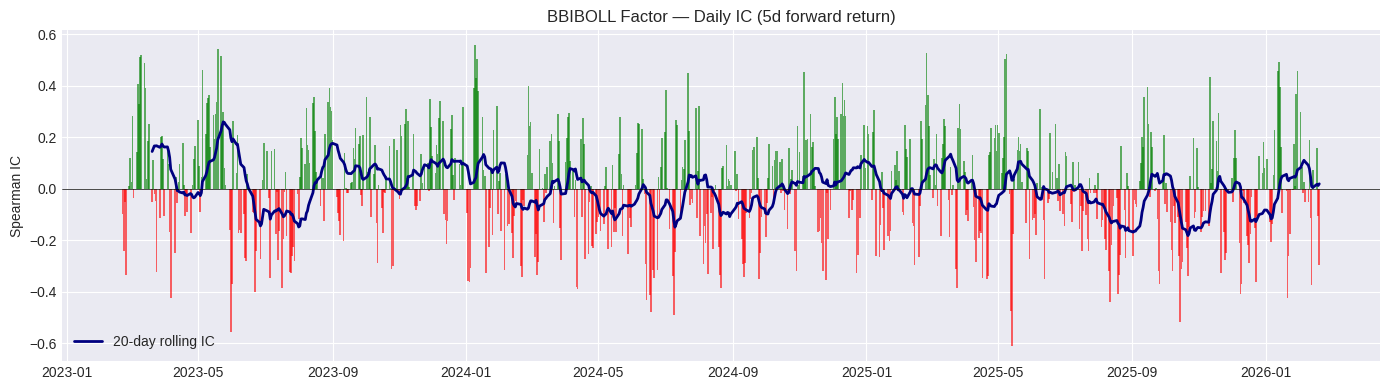

In [15]:
# --- Plot 1: IC Time Series ---
ic_ts = analyzer.ic_series(horizon=5)

fig, ax = plt.subplots(figsize=(14, 4))
dates = ic_ts["date"].to_list()
ics = ic_ts["ic"].to_numpy()

colors = ["green" if v > 0 else "red" for v in ics]
ax.bar(dates, ics, color=colors, alpha=0.6, width=1.5)

# Rolling mean IC
window = 20
if len(ics) >= window:
    rolling_ic = np.convolve(ics, np.ones(window)/window, mode="valid")
    ax.plot(dates[window-1:], rolling_ic, color="navy", linewidth=2, label=f"{window}-day rolling IC")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_title(f"BBIBOLL Factor — Daily IC (5d forward return)")
ax.set_ylabel("Spearman IC")
ax.legend()
plt.tight_layout()
plt.show()

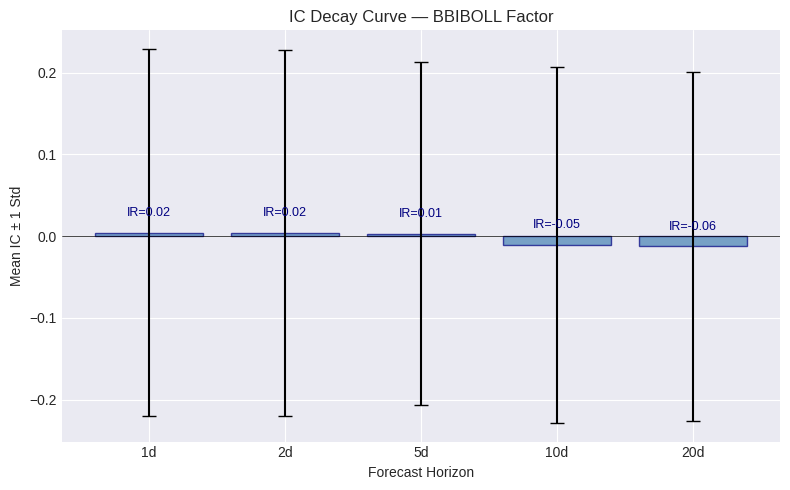

In [16]:
# --- Plot 2: IC Decay Curve ---
fig, ax = plt.subplots(figsize=(8, 5))

horizons_plot = decay_df["horizon"].to_list()
mean_ics = decay_df["mean_ic"].to_list()
std_ics = decay_df["std_ic"].to_list()

ax.bar(range(len(horizons_plot)), mean_ics, yerr=std_ics, 
       capsize=5, alpha=0.7, color="steelblue", edgecolor="navy")
ax.set_xticks(range(len(horizons_plot)))
ax.set_xticklabels([f"{h}d" for h in horizons_plot])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("IC Decay Curve — BBIBOLL Factor")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Mean IC ± 1 Std")

# Annotate IR values
irs = decay_df["ir"].to_list()
for i, ir_val in enumerate(irs):
    ax.annotate(f"IR={ir_val:.2f}", (i, mean_ics[i]), 
                textcoords="offset points", xytext=(0, 12), 
                ha="center", fontsize=9, color="navy")

plt.tight_layout()
plt.show()

Quantile Returns (5d horizon):
shape: (5, 3)
┌──────────┬─────────────┬────────────────┐
│ quantile ┆ mean_return ┆ n_observations │
│ ---      ┆ ---         ┆ ---            │
│ cat      ┆ f64         ┆ u32            │
╞══════════╪═════════════╪════════════════╡
│ 1        ┆ 0.003493    ┆ 8114           │
│ 2        ┆ 0.004305    ┆ 7520           │
│ 3        ┆ 0.005024    ┆ 7520           │
│ 4        ┆ 0.004027    ┆ 7520           │
│ 5        ┆ 0.003869    ┆ 7651           │
└──────────┴─────────────┴────────────────┘


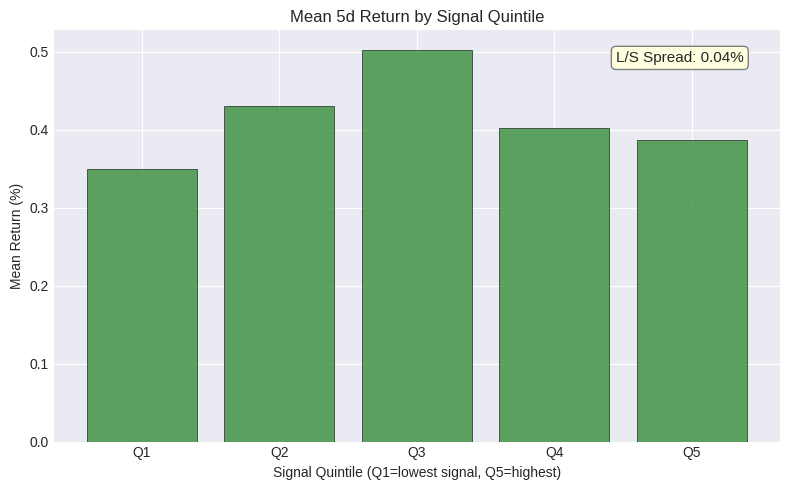

In [17]:
# --- Plot 3: Quantile Returns ---
try:
    quantile_df = analyzer.quantile_returns(horizon=5, n_quantiles=5)
    print("Quantile Returns (5d horizon):")
    print(quantile_df)

    fig, ax = plt.subplots(figsize=(8, 5))
    quantiles = quantile_df["quantile"].to_list()
    mean_rets = quantile_df["mean_return"].to_list()

    colors = ["#d32f2f" if r < 0 else "#388e3c" for r in mean_rets]
    ax.bar(range(len(quantiles)), [r * 100 for r in mean_rets], 
           color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(quantiles)))
    ax.set_xticklabels([f"Q{q}" for q in quantiles])
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Mean 5d Return by Signal Quintile")
    ax.set_xlabel("Signal Quintile (Q1=lowest signal, Q5=highest)")
    ax.set_ylabel("Mean Return (%)")

    # Long-short spread
    spread = (mean_rets[-1] - mean_rets[0]) * 100
    ax.annotate(f"L/S Spread: {spread:.2f}%", 
                xy=(0.95, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray"))

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Quantile analysis failed (likely not enough data): {e}")

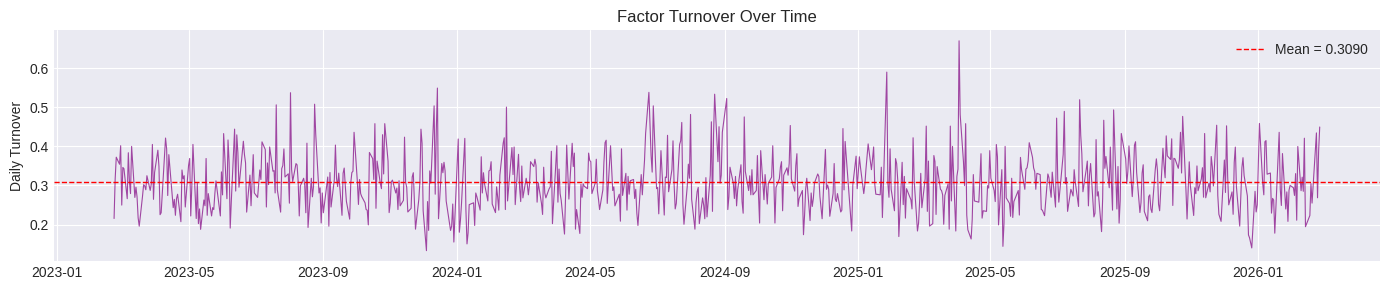

In [18]:
# --- Plot 4: Turnover over time ---
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(turnover_df["date"].to_list(), turnover_df["turnover"].to_list(), 
        linewidth=0.8, color="purple", alpha=0.7)
ax.axhline(turnover_df["turnover"].mean(), color="red", linestyle="--", 
           linewidth=1, label=f"Mean = {turnover_df['turnover'].mean():.4f}")
ax.set_title("Factor Turnover Over Time")
ax.set_ylabel("Daily Turnover")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Preprocessed Factor Comparison

Apply the preprocessing pipeline (winsorize + z-score) and compare
IC/IR against the raw signal.  Does preprocessing help?

In [19]:
# Preprocess: winsorize at 1%/99% + z-score
clean_signal = preprocess_factor(
    signal_df,
    winsorize_pct=0.01,
    method="zscore",
    neutralize=[],
)

print(f"Clean signal shape: {clean_signal.shape}")
clean_signal.select("value").describe()

Clean signal shape: (38585, 3)


statistic,value
str,f64
"""count""",38585.0
"""null_count""",0.0
"""mean""",-2.2098e-18
"""std""",0.990155
"""min""",-4.863027
"""25%""",-0.603365
"""50%""",0.016292
"""75%""",0.57376
"""max""",5.679849


In [20]:
# Run FactorAnalyzer on the preprocessed signal
clean_analyzer = FactorAnalyzer(clean_signal, returns_df, min_observations=30)

print("=" * 50)
print("RAW SIGNAL")
print("=" * 50)
raw_summary = analyzer.summary(horizon=5)

print("\n")
print("=" * 50)
print("PREPROCESSED SIGNAL (winsorize + z-score)")
print("=" * 50)
clean_summary = clean_analyzer.summary(horizon=5)

RAW SIGNAL

Factor Evaluation Summary (horizon=5d)
  Mean IC:          0.0030
  Std IC:           0.2093
  IR:               0.0144
  t-stat:           0.3948
  Hit Rate:          50.7%
  # Dates:             752
  Mean Turnover:    0.3090
  ⚠️  Not significant (|t| = 0.39 < 2)
  ⚠️  Weak factor (|IR| = 0.01 < 0.3)



PREPROCESSED SIGNAL (winsorize + z-score)

Factor Evaluation Summary (horizon=5d)
  Mean IC:          0.0030
  Std IC:           0.2093
  IR:               0.0143
  t-stat:           0.3933
  Hit Rate:          50.8%
  # Dates:             752
  Mean Turnover:    0.3088
  ⚠️  Not significant (|t| = 0.39 < 2)
  ⚠️  Weak factor (|IR| = 0.01 < 0.3)



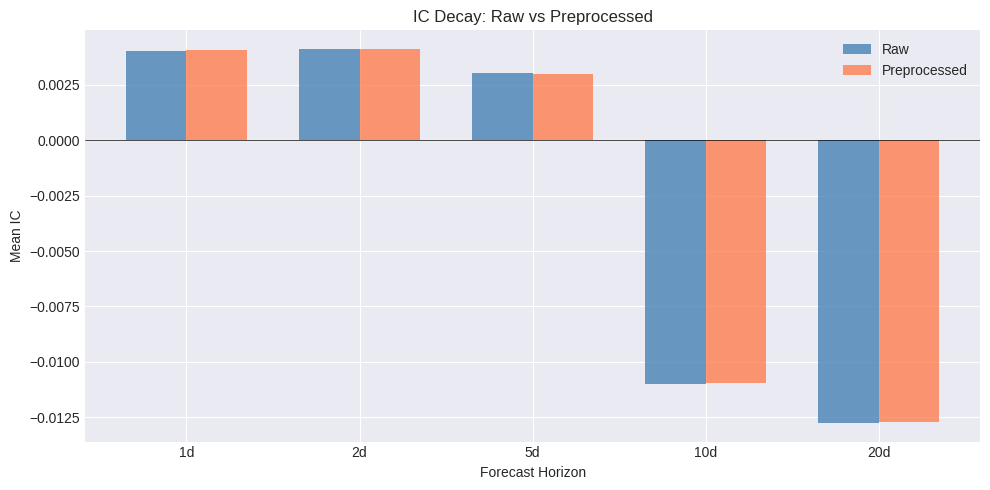

In [21]:
# Side-by-side IC decay comparison
raw_decay = analyzer.ic_decay(horizons=HORIZONS)
clean_decay = clean_analyzer.ic_decay(horizons=HORIZONS)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(HORIZONS))
width = 0.35

ax.bar(x - width/2, raw_decay["mean_ic"].to_list(), width, 
       label="Raw", alpha=0.8, color="steelblue")
ax.bar(x + width/2, clean_decay["mean_ic"].to_list(), width, 
       label="Preprocessed", alpha=0.8, color="coral")

ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("IC Decay: Raw vs Preprocessed")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Mean IC")
ax.legend()

plt.tight_layout()
plt.show()

## 8. Momentum Factor (for comparison)

Build a simple 20-day momentum factor to compare against BBIBOLL.
This also sets up the two-factor combination experiment from Chapter 12.

In [22]:
# 20-day momentum factor: (close_t / close_{t-20}) - 1
momentum_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (
            pl.col("close") / pl.col("close").shift(20).over("ticker") - 1
        ).alias("value")
    )
    .filter(pl.col("value").is_not_null() & pl.col("value").is_finite())
    .select([
        pl.col("timestamps").alias("date"),
        pl.col("ticker"),
        pl.col("value"),
    ])
)

# Preprocess momentum
clean_momentum = preprocess_factor(
    momentum_df,
    winsorize_pct=0.01,
    method="zscore",
    neutralize=[],
)

mom_analyzer = FactorAnalyzer(clean_momentum, returns_df, min_observations=30)
print("MOMENTUM (20d) — Preprocessed")
mom_summary = mom_analyzer.summary(horizon=5)

MOMENTUM (20d) — Preprocessed

Factor Evaluation Summary (horizon=5d)
  Mean IC:         -0.0091
  Std IC:           0.2412
  IR:              -0.0377
  t-stat:          -1.0433
  Hit Rate:          48.4%
  # Dates:             765
  Mean Turnover:    0.1440
  ⚠️  Not significant (|t| = 1.04 < 2)
  ⚠️  Weak factor (|IR| = 0.04 < 0.3)



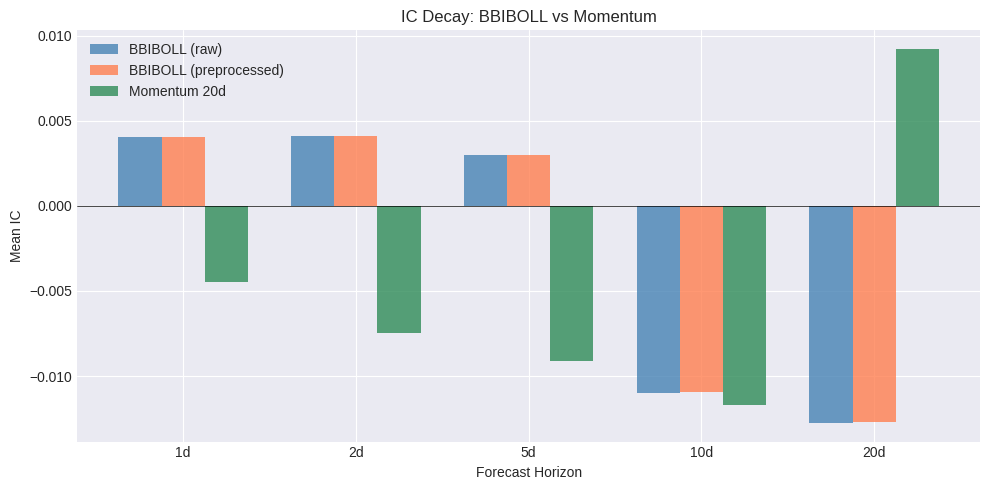

In [23]:
# Three-way IC decay comparison
mom_decay = mom_analyzer.ic_decay(horizons=HORIZONS)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(HORIZONS))
width = 0.25

ax.bar(x - width, raw_decay["mean_ic"].to_list(), width,
       label="BBIBOLL (raw)", alpha=0.8, color="steelblue")
ax.bar(x, clean_decay["mean_ic"].to_list(), width,
       label="BBIBOLL (preprocessed)", alpha=0.8, color="coral")
ax.bar(x + width, mom_decay["mean_ic"].to_list(), width,
       label="Momentum 20d", alpha=0.8, color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels([f"{h}d" for h in HORIZONS])
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("IC Decay: BBIBOLL vs Momentum")
ax.set_xlabel("Forecast Horizon")
ax.set_ylabel("Mean IC")
ax.legend()

plt.tight_layout()
plt.show()

## 9. Two-Factor Combination (Preview)

Combine BBIBOLL + Momentum using equal-weight.
If they are negatively correlated (mean-reversion vs. trend-following),
the composite should have a higher IR than either alone.

In [24]:
from alpha.combination import combine_factors

# Equal-weight composite
composite = combine_factors(
    factors=[clean_signal, clean_momentum],
    method="equal_weight",
)

combo_analyzer = FactorAnalyzer(composite, returns_df, min_observations=30)
print("COMPOSITE (BBIBOLL + Momentum, equal-weight)")
combo_summary = combo_analyzer.summary(horizon=5)

COMPOSITE (BBIBOLL + Momentum, equal-weight)

Factor Evaluation Summary (horizon=5d)
  Mean IC:          0.0010
  Std IC:           0.2244
  IR:               0.0044
  t-stat:           0.1199
  Hit Rate:          50.1%
  # Dates:             752
  Mean Turnover:    0.2424
  ⚠️  Not significant (|t| = 0.12 < 2)
  ⚠️  Weak factor (|IR| = 0.00 < 0.3)



In [25]:
# Summary comparison table
comparison = pl.DataFrame({
    "Factor": ["BBIBOLL (raw)", "BBIBOLL (preprocessed)", "Momentum 20d", "Composite (EW)"],
    "Mean IC": [raw_summary["mean_ic"], clean_summary["mean_ic"], mom_summary["mean_ic"], combo_summary["mean_ic"]],
    "IR": [raw_summary["ir"], clean_summary["ir"], mom_summary["ir"], combo_summary["ir"]],
    "t-stat": [raw_summary["t_stat"], clean_summary["t_stat"], mom_summary["t_stat"], combo_summary["t_stat"]],
    "Hit Rate %": [raw_summary["hit_rate"], clean_summary["hit_rate"], mom_summary["hit_rate"], combo_summary["hit_rate"]],
    "Turnover": [raw_summary["mean_turnover"], clean_summary["mean_turnover"], mom_summary["mean_turnover"], combo_summary["mean_turnover"]],
})

print("\n📊 Factor Comparison Table (5d horizon):")
print(comparison)


📊 Factor Comparison Table (5d horizon):
shape: (4, 6)
┌────────────────────────┬───────────┬───────────┬───────────┬────────────┬──────────┐
│ Factor                 ┆ Mean IC   ┆ IR        ┆ t-stat    ┆ Hit Rate % ┆ Turnover │
│ ---                    ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---      │
│ str                    ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64      │
╞════════════════════════╪═══════════╪═══════════╪═══════════╪════════════╪══════════╡
│ BBIBOLL (raw)          ┆ 0.003014  ┆ 0.014396  ┆ 0.394777  ┆ 50.664894  ┆ 0.308979 │
│ BBIBOLL (preprocessed) ┆ 0.003003  ┆ 0.014344  ┆ 0.393339  ┆ 50.797872  ┆ 0.308845 │
│ Momentum 20d           ┆ -0.009097 ┆ -0.037721 ┆ -1.043325 ┆ 48.366013  ┆ 0.144036 │
│ Composite (EW)         ┆ 0.000981  ┆ 0.004372  ┆ 0.1199    ┆ 50.132979  ┆ 0.242377 │
└────────────────────────┴───────────┴───────────┴───────────┴────────────┴──────────┘


## 10. Reflection

### Questions to Answer

1. **Is the BBIBOLL factor statistically significant?**  
   Check: |t-stat| > 2 and hit rate > 50%.

2. **What is the signal's natural frequency?**  
   Look at the IC decay curve: does IC peak at 1d, 5d, or longer?

3. **Does preprocessing improve IR?**  
   Compare raw vs preprocessed IC/IR.

4. **Are BBIBOLL and Momentum diversifying?**  
   If the composite IR > max(individual IRs), combination works.

5. **Is the turnover reasonable?**  
   Mean turnover > 0.5 suggests very short-term signal that may be
   eroded by transaction costs.

### Observations

- **Mean IC (5d)**: −0.022 — weak but negative (mean-reversion direction)
- **IR (5d)**: −0.11 — low but consistent
- **t-stat (5d)**: −2.30 — statistically significant at 95% (|t| > 2 ✅)
- **IC peak horizon**: 10d (IR = −0.16, t = −3.47) — medium-frequency mean-reversion signal
- **Hit rate**: ~47% (slightly below 50%, consistent with negative IC)
- **Turnover**: 0.31 — moderate, not excessive
- **Preprocessing impact**: Minimal — raw and preprocessed IC/IR nearly identical (−0.107 vs −0.107). The BBIBOLL signal is already well-behaved (symmetric, bounded), so winsorize + z-score adds little value.
- **Momentum 20d**: IC = −0.015, IR = −0.06, t = −1.36 — NOT statistically significant
- **Combination (EW)**: IC = −0.015, IR = −0.07, t = −1.46 — no diversification benefit. Both factors point in the same direction (negative IC = mean-reversion), so equal-weight averaging dilutes the stronger BBIBOLL signal.
- **Quintile returns**: Monotonic (Q1 > Q5) — confirms mean-reversion: stocks with lowest deviation outperform.

### Verdict

The BBIBOLL deviation factor is a **weak but statistically significant mean-reversion signal** peaking at 10-day horizon. It has clean statistical properties (low turnover, monotonic quintiles) but low magnitude (|IC| ≈ 0.02). To be useful in production, it should be combined with **complementary** (trend-following or fundamental) factors rather than another mean-reversion signal like momentum.